In [2]:
from pandas import read_csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
from pandas import read_csv
import math
import random
import csv
import numpy as np
import pandas as pd
from numpy import matrix
import statsmodels.api as sm
import pylab as pl
import scipy.linalg as sl

In [3]:
filename = 'XGDP 4.4 first with n = 400.csv'
data4 = read_csv(filename)
#Table1的数据的输出
print([data4['K1'].median(axis=0),(data4['K1'].mean(axis=0) - 3),
 np.std((data4.K1), ddof=1),(data4['RI1'].mean(axis=0)),np.sum(data4.K1 == 3)/len(data4.K1)])
print([data4['K2'].median(axis=0),(data4['K2'].mean(axis=0) - 3),
 np.std((data4.K2), ddof=1),(data4['RI2'].mean(axis=0)),np.sum(data4.K2 == 3)/len(data4.K2)])
print([data4.ACC1.mean(),data4.ACC2.mean(),data4.ACC_final.mean(),data4.ACCp1.mean(),data4.ACCp2.mean(),data4.ACC_pre.mean()])

[np.float64(3.0), np.float64(-0.004999999999999893), np.float64(0.07071067811865477), np.float64(0.9580021303258145), np.float64(0.995)]
[np.float64(3.0), np.float64(-0.03500000000000014), np.float64(0.20974979111878003), np.float64(0.9481091478696743), np.float64(0.97)]
[np.float64(0.957575), np.float64(0.9690125), np.float64(0.9359999999999999), np.float64(0.9560499999999998), np.float64(0.9629749999999998), np.float64(0.9312)]


In [5]:
print([data4.beta_0.mean(axis=0) -1,np.std((data4.beta_0),ddof=1),
       data4.beta_0.var(axis=0)+ (data4.beta_0.mean(axis=0) -1)**2])
#有异常值
#beta1的输出
print([data4['beta_1'].mean(axis=0) -1,np.std((data4.beta_1),ddof=1),
       data4['beta_1'].var(axis=0)+ (data4['beta_1'].mean(axis=0) -1)**2])


#beta2的输出
print([data4.beta_2.mean(axis=0) -1,np.std((data4.beta_2),ddof=1),
       data4.beta_2.var(axis=0)+ (data4.beta_2.mean(axis=0) -1)**2])

#alpha11的输出
print([data4.alpha1_1.mean(axis=0) +2,np.std((data4.alpha1_1),ddof=1),
       data4.alpha1_1.var(axis=0)+ (data4.alpha1_1.mean(axis=0) +2)**2])
#alpha12的输出
print([data4.alpha1_2.mean(axis=0) + 0,np.std((data4.alpha1_2),ddof=1),
       data4.alpha1_2.var(axis=0)+ (data4.alpha1_2.mean(axis=0) + 0)**2
      ])

#alpha13的输出
print([data4.alpha1_3.mean(axis=0) -2,np.std((data4.alpha1_3),ddof=1),
       data4.alpha1_3.var(axis=0)+ (data4.alpha1_3.mean(axis=0) -2)**2])

#alpha21的输出
print([data4.alpha2_1.mean(axis=0) + 1.5,np.std((data4.alpha2_1),ddof=1),
       data4.alpha2_1.var(axis=0)+ (data4.alpha2_1.mean(axis=0) + 1.5)**2])
#alpha22的输出
print([data4.alpha2_2.mean(axis=0) -0.5,np.std((data4.alpha2_2),ddof=1),
       data4.alpha2_2.var(axis=0)+ (data4.alpha2_2.mean(axis=0) -0.5)**2])
#alpha23的输出
print([data4.alpha2_3.mean(axis=0) -2.5,np.std((data4.alpha2_3),ddof=1),
       data4.alpha2_3.var(axis=0)+ (data4.alpha2_3.mean(axis=0) -2.5)**2])

[np.float64(0.006747793345168063), np.float64(0.06941706373985132), np.float64(0.004864261453291676)]
[np.float64(0.001925306349751299), np.float64(0.030705709763303515), np.float64(0.0009465474166086255)]
[np.float64(-0.0038060929670911126), np.float64(0.031939059976261994), np.float64(0.001034589895841401)]
[np.float64(0.0076586515795307175), np.float64(0.05148532508087811), np.float64(0.0027093936427003444)]
[np.float64(-0.0055348811135366915), np.float64(0.056974829911730224), np.float64(0.003276766152411574)]
[np.float64(0.009981415234570967), np.float64(0.049416599221230595), np.float64(0.002541628928676654)]
[np.float64(-0.009508742777126988), np.float64(0.04834384913833709), np.float64(0.002427543938711861)]
[np.float64(-0.00322898467196181), np.float64(0.039785419994328323), np.float64(0.0015933059861368646)]
[np.float64(-0.0059307106428168055), np.float64(0.03638172126660723), np.float64(0.0013588029710499211)]


In [6]:
filename = 'XGDP 4.4 first with n = 400 pre1.csv'
pre1 = read_csv(filename)
filename = 'XGDP 4.4 first with n = 400 pre2.csv'
pre2 = read_csv(filename)
x_min,x_max = 0,1#取横坐标的取值范围
y_min,y_max = 0,1#取纵坐标的取值范围
xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))#生成网格点

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


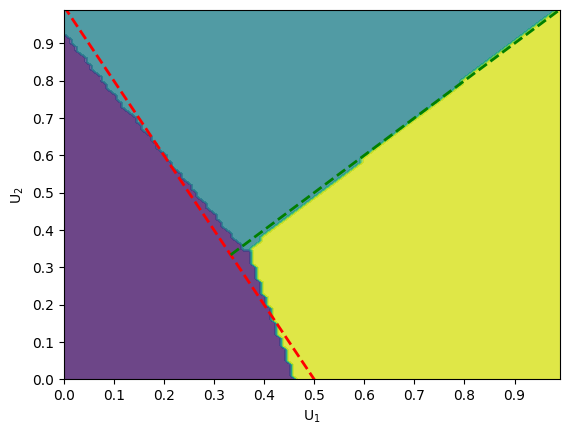

In [7]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8)
plt.contour(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,linewidths=0)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)

x = np.linspace(0, 1, 50)
y1 = 1-2*x
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')
x = np.linspace(1/3, 1, 50)
y1 = x
plt.plot(x, y1, color='green',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('img41.eps', format='eps', dpi=300)
#plt.savefig("img41.png")
plt.show()
#beta1通过投票的最终预测

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


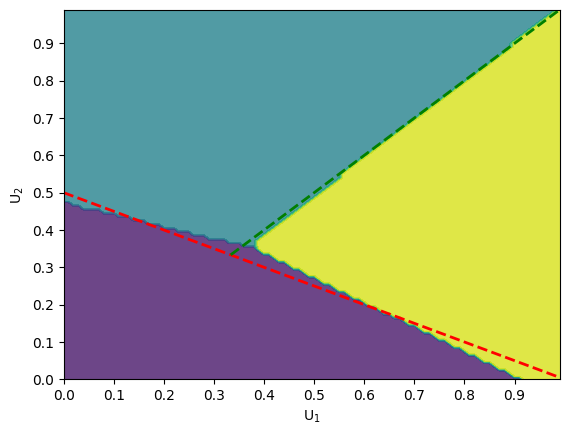

In [8]:
Pre2 = matrix(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的40000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8)
plt.contour(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8,linewidths=0)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)

x = np.linspace(0, 1, 50)
y1 = 1/2 - 0.5 * x
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')

x = np.linspace(1/3, 1, 50)
y1 = x
plt.plot(x, y1, color='green',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('img42.eps', format='eps', dpi=300)
#plt.savefig("img42.png")
plt.show()
#beta1通过投票的最终预测

####  n = 800

In [9]:
filename = 'XGDP 4.4 first with n = 800.csv'
data4_4 = read_csv(filename)
#Table1的数据的输出
print([data4_4['K1'].median(axis=0),(data4_4['K1'].mean(axis=0) - 3),
 np.std((data4_4.K1), ddof=1),(data4_4['RI1'].mean(axis=0)),np.sum(data4_4.K1 == 3)/len(data4_4.K1)])
print([data4_4['K2'].median(axis=0),(data4_4['K2'].mean(axis=0) - 3),
 np.std((data4_4.K2), ddof=1),(data4_4['RI2'].mean(axis=0)),np.sum(data4_4.K2 == 3)/len(data4_4.K2)])
print([data4_4.ACC1.mean(),data4_4.ACC2.mean(),data4_4.ACC_final.mean(),data4_4.ACCp1.mean(),data4_4.ACCp2.mean(),data4_4.ACC_pre.mean()])

[np.float64(3.0), np.float64(0.0), np.float64(0.0), np.float64(0.9605128754693366), np.float64(1.0)]
[np.float64(3.0), np.float64(-0.009999999999999787), np.float64(0.09974842727441166), np.float64(0.9161457133917398), np.float64(0.99)]
[np.float64(0.9694812500000001), np.float64(0.9778125), np.float64(0.9531562499999999), np.float64(0.971875), np.float64(0.9729249999999999), np.float64(0.9525999999999999)]


In [10]:
print([data4_4.beta_0.mean(axis=0) -1,np.std((data4_4.beta_0),ddof=1),
       data4_4.beta_0.var(axis=0)+ (data4_4.beta_0.mean(axis=0) -1)**2])
#有异常值
#beta1的输出
print([data4_4['beta_1'].mean(axis=0) -1,np.std((data4_4.beta_1),ddof=1),
       data4_4['beta_1'].var(axis=0)+ (data4_4['beta_1'].mean(axis=0) -1)**2])


#beta2的输出
print([data4_4.beta_2.mean(axis=0) -1,np.std((data4_4.beta_2),ddof=1),
       data4_4.beta_2.var(axis=0)+ (data4_4.beta_2.mean(axis=0) -1)**2])

#alpha11的输出
print([data4_4.alpha1_1.mean(axis=0) +2,np.std((data4_4.alpha1_1),ddof=1),
       data4_4.alpha1_1.var(axis=0)+ (data4_4.alpha1_1.mean(axis=0) +2)**2])
#alpha12的输出
print([data4_4.alpha1_2.mean(axis=0) + 0,np.std((data4_4.alpha1_2),ddof=1),
       data4_4.alpha1_2.var(axis=0)+ (data4_4.alpha1_2.mean(axis=0) + 0)**2
      ])

#alpha13的输出
print([data4_4.alpha1_3.mean(axis=0) -2,np.std((data4_4.alpha1_3),ddof=1),
       data4_4.alpha1_3.var(axis=0)+ (data4_4.alpha1_3.mean(axis=0) -2)**2])

#alpha21的输出
print([data4_4.alpha2_1.mean(axis=0) + 1.5,np.std((data4_4.alpha2_1),ddof=1),
       data4_4.alpha2_1.var(axis=0)+ (data4_4.alpha2_1.mean(axis=0) + 1.5)**2
    ])
#alpha22的输出
print([data4_4.alpha2_2.mean(axis=0) -0.5,np.std((data4_4.alpha2_2),ddof=1),
       data4_4.alpha2_2.var(axis=0)+ (data4_4.alpha2_2.mean(axis=0) -0.5)**2
      ])
#alpha23的输出
print([data4_4.alpha2_3.mean(axis=0) -2.5,np.std((data4_4.alpha2_3),ddof=1),
       data4_4.alpha2_3.var(axis=0)+ (data4_4.alpha2_3.mean(axis=0) -2.5)**2])

[np.float64(-0.0009859937510739991), np.float64(0.04638551964016093), np.float64(0.0021525886159649127)]
[np.float64(-0.002132279396746095), np.float64(0.020688181462972206), np.float64(0.0004325474676706546)]
[np.float64(-0.0010826261447220986), np.float64(0.020085711618476738), np.float64(0.0004046078905898472)]
[np.float64(0.0034502730736079013), np.float64(0.035395001096300956), np.float64(0.0012647104868896096)]
[np.float64(0.0012704640275328317), np.float64(0.03914350247087941), np.float64(0.0015338278645329975)]
[np.float64(0.007341107513801237), np.float64(0.030041367332233424), np.float64(0.0009563756107193706)]
[np.float64(-0.0026954021430378727), np.float64(0.030720976389896557), np.float64(0.0009510435830612748)]
[np.float64(-0.00017896668654387993), np.float64(0.025442889169886754), np.float64(0.0006473726383860332)]
[np.float64(-0.003289374160093672), np.float64(0.02663873049825314), np.float64(0.0007204419449236539)]


In [11]:
filename = 'XGDP 4.4 first with n = 800 pre1.csv'
pre1 = read_csv(filename)
filename = 'XGDP 4.4 first with n = 800 pre2.csv'
pre2 = read_csv(filename)
x_min,x_max = 0,1#取横坐标的取值范围
y_min,y_max = 0,1#取纵坐标的取值范围
xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))#生成网格点

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


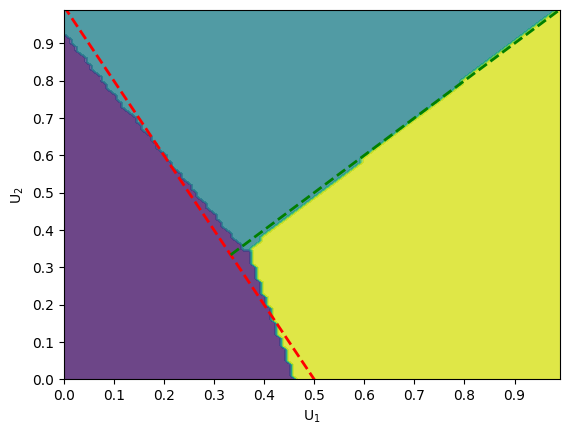

In [11]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8)
plt.contour(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,linewidths=0)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)

x = np.linspace(0, 1, 50)
y1 = 1-2*x
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')
x = np.linspace(1/3, 1, 50)
y1 = x
plt.plot(x, y1, color='green',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
#Table1的数据的输出
plt.savefig('img43.eps', format='eps', dpi=300)
#plt.savefig("img43.png")
plt.show()
#beta1通过投票的最终预测

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


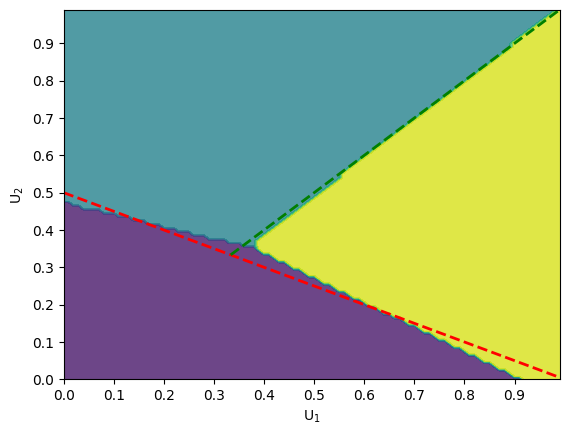

In [12]:
Pre2 = matrix(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的40000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8)
plt.contour(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8,linewidths=0)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)

x = np.linspace(0, 1, 50)
y1 = 1/2 - 0.5 * x
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')

x = np.linspace(1/3, 1, 50)
y1 = x
plt.plot(x, y1, color='green',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
#plt.savefig("img44.png")
plt.savefig('img44.eps', format='eps', dpi=300)
plt.show()
#beta1通过投票的最终预测